# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Auliya Az Zahrah Salsabilah
- **Email:** cdcc117d6x2664@student.devacademy.id
- **ID Dicoding:** CDCC117D6X2664

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

### Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana tren jumlah order dan total revenue per bulan selama periode Januari 2017 hingga Agustus 2018, dan apakah terdapat pola musiman yang dapat dijadikan dasar perencanaan kampanye promosi?
- **Pertanyaan 2:** Kota mana yang memiliki jumlah transaksi dan kontribusi revenue tertinggi selama 2017-2018, sehingga tim bisnis dapat memprioritaskan strategi pemasaran dan ekspansi pasar secara geografis?
- **Pertanyaan 3:** Kategori produk apa yang menghasilkan revenue tertinggi dan memiliki volume penjualan terbanyak selama periode 2017-2018, sehingga tim operasional dapat mengoptimalkan pengelolaan stok dan strategi promosi?
- **Pertanyaan 4:** Metode pembayaran apa yang paling sering digunakan oleh pelanggan dan memberikan kontribusi terbesar terhadap total revenue selama periode 2017-2018, sehingga bisnis dapat merancang insentif pembayaran yang tepat sasaran?

## Import Semua Packages/Library yang Digunakan

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**## Data Wrangling**

### Gathering Data

#### customers_dataset.csv

In [102]:

url = 'https://drive.google.com/uc?id=15rUnF-xnIriPmuHGjZjrXyvW6X93-ZO-'
customers_df = pd.read_csv(url)
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Pada kolom `customer_city` didapatkan menggunakan fort huruf kecil atau lowercase, sehingga perlu dilakukan standarisasi untuk menjaga konsistensi pada penulisan.
- Terdapat perbedaan antara `customer_id` dan `customer_unique_id`, yang berarti satu pelanggan dapat memiliki lebih dari satu transaksi. Dengan begitu, keadaan ini bisa dimanfaatkan untuk dilakukan analisis perilaku pelanggan seperti repeat order.

#### orders_dataset.csv

In [103]:
url = 'https://drive.google.com/uc?id=10bU8NhwSzJjD-YXQhd1heZDQvK5-S6wc'
orders_df = pd.read_csv(url)
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**

- Pada dataset ini memiliki kolom timestamp yang lengkap, sehingga sangat cocok untuk dilakukan analisis berbasis waktu seperti tren penjualan, durasi, durasi pengiriman, serta keterlambatan dibandingkan estimasi
- Pada kolom 'customer_id' dapat dilakukan integrasi dengan dataset pelanggan untuk dilakukan analisis lebih lanjut seperti pembelian dan segmentasi customer

#### order_items_dataset.csv

In [104]:
url = 'https://drive.google.com/uc?id=1j_0ECYojgX6s56kJyfHOHonQJsUey1ba'
order_items_df = pd.read_csv(url)
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Dataset order_items berisikan detail harga produk dan biaya pengiriman yang dapat digunakan untuk menghitung total revenue per transaksi .
- Terdapat kolom 'order_id' yang dapat membantu untuk melakukan intergasi dengan dataset orders untuk analisis tren jumlah order dan revenue untuk per waktu.
- Terdapat kolom 'product_id' yang memungkinkan untuk dilakukan penggabungan dengan dataset products untuk melakukan identifikasi kategori produk yang paling banyak terjual dan menghasilkan revenue tertinggi.

#### products_dataset.csv

In [105]:
url = 'https://drive.google.com/uc?id=1U1r1Qr72uhTwXP-RJ2RO8NY7mswgSzBA'
products_df = pd.read_csv(url)
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Terdapat kolom `product_id` yang bisa digunakan untuk melakukan integrasi dengan dataset `order_items` untuk menghitung jumlah penjualan dan total revenue per kategori produk.
- Terdapat beberpa kolom numerik yang berpotensi memiliki missing value dan perlu dilakukan pengecekan lebih lanjut pada tahap data cleaning.

#### order_payments_dataset.csv

In [106]:
url = 'https://drive.google.com/uc?id=1wvsAoCJxybO6lEMkqgCgTNK3kgqhf2wT'
order_payments_df = pd.read_csv(url)
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**
- Terdapat kolom `Payments_installments` yang dapat digunakan untuk memahami preferensi pembayaran yang dilakukan oleh pelanggan.
- Pada satu `order_id` dapat memiliki lebih dari satu 'payment_sequential', yang berarti dalam satu transaksi dapat dibayar dengan lebih daru satu metode atau tahap pembayaran.

### Assessing Data

#### Menilai Tabel Customers

In [107]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [108]:
missing_df = customers_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,customer_id,0
1,customer_unique_id,0
2,customer_zip_code_prefix,0
3,customer_city,0
4,customer_state,0


In [109]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [110]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Steps to Take:**
- Melakukan perubahan tipe data pada `customer_zip_code_prefix` dari semula integer menjadi string, hal ini karena kolom tersebut merupakan kode untuk wilayah.
- Melakukan standarisasi format untuk penulisan pada kolom `customer_city`
- Meskipun tidak ditemukan duplikasi, tetap dilakukan validasi pada kolom `customer_unique_id` untuk memastikan keunikan data pelanggan.


**Insight:**
- Kolom `customer_zip_code_prefix` bertipe integer, padahal merupakan kode wilayah. Hal ini berpotensi menyebabkan hilangnya leading zero, sehingga perlu dikonversi menjadi string pada tahap cleaning.
- Dataset ini dapat diintegrasikan dengan dataset orders melalui `customer_id` untuk menghubungkan data pelanggan dengan aktivitas transaksi.

#### Menilai Tabel Orders

In [111]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [112]:
missing_df = orders_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,order_id,0
1,customer_id,0
2,order_status,0
3,order_purchase_timestamp,0
4,order_approved_at,160
5,order_delivered_carrier_date,1783
6,order_delivered_customer_date,2965
7,order_estimated_delivery_date,0


In [113]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [114]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Steps to Take:**
- Mengonversi kolom yang bertipe tanggal menjadi tipe datetime, untuk memudahkan analisis berbasis waktu
- Menangani missing value pada kolom terkait pengiriman
- Melakukan validasi urutan waktu untuk memastikan bahwa proses order berjalan secara logis


**Insight:**
- Dataset ini mencatat seluruh transaksi pembelian hingga pengiriman
- Terdapat missing value yang menunjukkan tidak semua pesanan selesai diproses
- Dataset dapat diintergrasikan dengan dataset lain

#### Menilai Tabel Order Items

In [115]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [116]:
missing_df = order_items_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,order_id,0
1,order_item_id,0
2,product_id,0
3,seller_id,0
4,shipping_limit_date,0
5,price,0
6,freight_value,0


In [117]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [118]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Steps to Take:**
- Mengonversi kolom `shipping_limit_date` menjadi tipe datetime.
- Melakukan pengecekan terhadap nilai ekstrem (outlier) pada kolom `price` dan `freight_value`.
- Menghitung total nilai transaksi dengan menggabungkan `price` dan `freight_value`.

**Insight:**
- Satu `order_id` dapat berdiri dari beberapa item, sehingga untuk melakukan penting untuk melakukan agregasi data pada level order saat akan melakukan analisis
- Dataset ini adalah sumber utama untuk melakukan perhitungan total revenue karena mengandung informais harga produk dan biaya pengiriman


#### Menilai Tabel Products

In [119]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [120]:
missing_df = products_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,product_id,0
1,product_category_name,610
2,product_name_lenght,610
3,product_description_lenght,610
4,product_photos_qty,610
5,product_weight_g,2
6,product_length_cm,2
7,product_height_cm,2
8,product_width_cm,2


In [121]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [122]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Steps to Take:**
- Menangani missing value pada `product_category_name` yang dapat diisi dengan "Uknown" dan kolom numerik dapat diisikan dengan median atau dibiarkan saja
- Mengubah tipe data kolom panjang menjadi integer
- Melakukan pengecekan terhadap nilai yang tidak wajar


**Insight:**
- Adanya missing value pada beberapa kolom menunjukkan bahwa data produk belum sepenuhnya lengkap dan perlu dilakukan pembersihan sebelum analisis lebih lanjut.
- Dataset memiliki peran penting untuk menyediakan informasi kategori produk untuk analisis penjualan berdasarkan kategori

#### Menilai Tabel Order Payments

In [123]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [124]:
missing_df = order_payments_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,order_id,0
1,payment_sequential,0
2,payment_type,0
3,payment_installments,0
4,payment_value,0


In [125]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


In [126]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Steps to Take:**
- Melakukan pengecekan nilai yang memiliki keunikan pada kolom `payment_type` untuk memasiktn konsistensi ketgori
- Memvalidasi nilai pada kolom `payment_value` untuk mendeteksi nilai nol atau outlier
- Melakukan agregasi data pembayaran pada level `order_id` jika diperlukan unuk analisis lebih lanjut mengenai total transaksi per order


**Insight:**
- Dataset ini tidak memiliki missing value, sehingga siap digunakan untuk melakukan analisis
- Memiliki data yang kemunkinan salam satu order memiliki lebih dari satu pembayaran hal ini menunjukkan, bahwa fleksibilitas metode pelanggan, dapat menjadi insight tambahan terkait perilaku pembayaran

### Cleaning Data

#### Membersihkan Tabel Customers

In [127]:
# Melakukan drop duplikat
customers_df = customers_df.drop_duplicates()
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [128]:
# Mengubah zip code menjadi string

customers_df['customer_zip_code_prefix'] = (
    customers_df['customer_zip_code_prefix']
    .astype(str)
    .str.zfill(5)
)

customers_df[['customer_zip_code_prefix']].head()

,customer_zip_code_prefix
0,14409
1,09790
2,01151
3,08775
4,13056


In [129]:
# Menerapkan Standarisasi terhadap penulisan kata
customers_df['customer_city'] = (
    customers_df['customer_city']
    .str.strip()
    .str.title()
)

customers_df['customer_city'].unique()[:10]

array(['Franca', 'Sao Bernardo Do Campo', 'Sao Paulo', 'Mogi Das Cruzes',
       'Campinas', 'Jaragua Do Sul', 'Timoteo', 'Curitiba',
       'Belo Horizonte', 'Montes Claros'], dtype=object)

In [130]:
# Melakukan normalisasi terhadap state agar menjadi uppercase yang konsisten
customers_df['customer_state'] = customers_df['customer_state'].str.upper()

customers_df['customer_state'].unique()

array(['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA',
       'MS', 'CE', 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB',
       'TO', 'PI', 'AC', 'SE', 'RR'], dtype=object)

In [131]:
# cek missing value
missing_df = customers_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,customer_id,0
1,customer_unique_id,0
2,customer_zip_code_prefix,0
3,customer_city,0
4,customer_state,0


**Insight:**
- Proses cleaning berhasil mengubah tipe data pada kolom `customer_zip_code_prefix` menjadi string, sehingga lebih sesuai sebagai kode wilayah.
- Standarisasi pada kolom `customer_city` menghasilkan format penulisan yang konsisten. sehingga bisa mengurangi potensi duplikasi saat analisis berbasis lokasi
- Normalisasi pada kolom `customer_state` untuk memastikan seluruh data memiliki format yang seragam yaitu uppercase, sehingga memudahkan untuk proses agregasi data
- Pada dataset ini dari sebelumnya tidak memiliki missing value maupun duplikasi, sehingga data ini sudah siap untuk dilakukan analisis

#### Membersihkan Tabel Orders

In [132]:
# Melakukan convert kolom yang bertipe tanggal menjadi datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# hasilnya
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [195]:
# Melakukan pengecekan missing value
missing_df = orders_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,order_id,0
1,customer_id,0
2,order_status,0
3,order_purchase_timestamp,0
4,order_approved_at,160
5,order_delivered_carrier_date,1783
6,order_delivered_customer_date,2965
7,order_estimated_delivery_date,0
8,delivery_time,2965


In [134]:
# Melakukan validasi urutan waktu
invalid_orders = orders_df[
    orders_df['order_purchase_timestamp'] > orders_df['order_delivered_customer_date']
]

print("Jumlah data tidak valid:", len(invalid_orders))
invalid_orders.head()

Jumlah data tidak valid: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


**Insight:**
- Setelah dilakukan konversi tipe data, seluruh kolom waktu kini bertipe datetime sehingga memungkinkan analisis berbasis waktu seperti tren penjualan dan durasi pengiriman.
- Missing value pada kolom pengiriman tidak dihapus karena mencerminkan kondisi nyata bahwa tidak semua pesanan berhasil diselesaikan.
- Tidak ditemukan ketidaksesuaian urutan waktu, yang menunjukkan bahwa data memiliki konsistensi yang baik.
- Dataset ini siap digunakan untuk analisis lanjutan seperti tren order dan performa pengiriman.

#### Membersihkan Tabel Order Items


In [135]:
# Melakukan perubahan shipping_limit menjadi datetime
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

print("Tipe data shipping_limit_date:", order_items_df['shipping_limit_date'].dtype)
order_items_df.head()

Tipe data shipping_limit_date: datetime64[ns]


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [136]:
missing_df = order_items_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,order_id,0
1,order_item_id,0
2,product_id,0
3,seller_id,0
4,shipping_limit_date,0
5,price,0
6,freight_value,0


In [137]:
# Cek nilai nol atau negatif
order_items_df[order_items_df['price'] <= 0]
order_items_df[order_items_df['freight_value'] <= 0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
114,00404fa7a687c8c44ca69d42695aae73,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-15 04:31:26,99.9,0.0
258,00a870c6c06346e85335524935c600c0,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-05-14 00:14:29,69.9,0.0
483,011c899816ea29773525bd3322dbb6aa,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-07 05:30:45,99.9,0.0
508,012b3f6ab7776a8ab3443a4ad7bef2e6,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
509,012b3f6ab7776a8ab3443a4ad7bef2e6,2,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
...,...,...,...,...,...,...,...
111094,fc698f330ec7fb74859071cc6cb29772,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-04-25 02:31:57,53.9,0.0
111497,fd4907109f6bac23f07064af84bec02d,1,7a10781637204d8d10485c71a6108a2e,4869f7a5dfa277a7dca6462dcf3b52b2,2018-04-30 11:31:32,219.0,0.0
111649,fd95e4b85ebbb81853d4a6be3d61432b,1,53b36df67ebb7c41585e8d54d6772e08,4869f7a5dfa277a7dca6462dcf3b52b2,2018-05-04 11:10:31,106.9,0.0
112182,fee19a0dc7358b6962a611cecf6a37b4,1,f1c7f353075ce59d8a6f3cf58f419c9c,37be5a7c751166fbc5f8ccba4119e043,2017-09-07 22:06:31,195.0,0.0


In [138]:
# Menambahkan total harga (price + ongkir)
order_items_df['total_price'] = (
    order_items_df['price'] + order_items_df['freight_value']
)

order_items_df[['price', 'freight_value', 'total_price']].head()

,price,freight_value,total_price
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [139]:
# Validasi struktur order
order_items_df.groupby('order_id')['order_item_id'].count().head()

,order_item_id
order_id,
00010242fe8c5a6d1ba2dd792cb16214,1
00018f77f2f0320c557190d7a144bdd3,1
000229ec398224ef6ca0657da4fc703e,1
00024acbcdf0a6daa1e931b038114c75,1
00042b26cf59d7ce69dfabb4e55b4fd9,1


**Insight:**
- Kolom `shipping_limit_date`, telah dikonversi menjadi datetime sehingga sudah dapat digunakan untuk dilakukan analisis berbasis waktu
- Tidak perlu penanganan missinng value, karena dataset tidak memiliki missing value
- Menambahkan kolom 'total_price' agar bisa digunakan untuk perhitungan revenue yang lebih akurat

#### Membersihkan Tabel Products

In [140]:
# mengisi missing kategori Unknown
products_df['product_category_name'] = products_df['product_category_name'].fillna('Unknown')

# Validasi
products_df['product_category_name'].isna().sum()

np.int64(0)

In [141]:
# menangani missing value numerik
num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in num_cols:
    products_df[col] = products_df[col].fillna(products_df[col].median())

In [142]:
# missing value sudah berhasil terhandle
missing_df = products_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

,Kolom,Jumlah Missing Value
0,product_id,0
1,product_category_name,0
2,product_name_lenght,0
3,product_description_lenght,0
4,product_photos_qty,0
5,product_weight_g,0
6,product_length_cm,0
7,product_height_cm,0
8,product_width_cm,0


In [143]:
# pengubahan tipe data
products_df['product_name_lenght'] = products_df['product_name_lenght'].astype('Int64')
products_df['product_description_lenght'] = products_df['product_description_lenght'].astype('Int64')
products_df['product_photos_qty'] = products_df['product_photos_qty'].astype('Int64')

products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32951 non-null  Int64  
 3   product_description_lenght  32951 non-null  Int64  
 4   product_photos_qty          32951 non-null  Int64  
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: Int64(3), float64(4), object(2)
memory usage: 2.4+ MB


In [176]:
# memeriksa nilai yang mungkin tidak wajar
products_df.describe()

products_df[products_df['product_weight_g'] <= 0]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51,529,1,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48,528,1,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53,528,1,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53,528,1,0.0,30.0,25.0,30.0


**Insight:**
- Missing value sudah berhasil ditangani
- kolom kategoru produk yang seblumnya ksosong sudah diisi dengan "Uknown"
- Sudah melakukan perubahan tipe data pad akolom numerik menjadi dengan sesuai dengan yang seharusnya

#### Membersihkan Tabel Order Payments

In [145]:
# memeriksa nilai yang unik
order_payments_df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [146]:
# memeriksa validasi nilai payment_value
order_payments_df[order_payments_df['payment_value'] <= 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [147]:
# Melakukan agregasi pembayaran untuk per ordernya

payments_agg = (
    order_payments_df
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)

payments_agg.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [148]:
# melakuan validasi multi-payment
order_payments_df.groupby('order_id').size().value_counts().head()

,count
1,96479
2,2382
3,301
4,108
5,52


In [149]:
# hasil validasi setelah dilakukan cleaning kecil-kecilan
order_payments_df.info()

missing_df = order_payments_df.isna().sum().reset_index()
missing_df.columns = ['Kolom', 'Jumlah Missing Value']
missing_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,Kolom,Jumlah Missing Value
0,order_id,0
1,payment_sequential,0
2,payment_type,0
3,payment_installments,0
4,payment_value,0


**Insight:**
- Dataset ini ternyata tidak memiliki missing value, jadi tidak memerlukan penanganan
- Juga tidak ditemukan nilai payment yang tidak wajar, sehingga data pembauaran dapat dianggap valid
- Ditemukan bahwa satu order dapat memiliki lebih dari satu pembayaran, yang menunjukkan fleksibilitas metode pembayaran pelanggan.
- Data telah siap digunakan untuk analisis metode pembayaran dan kontribusinya terhadap total revenue.

## Exploratory Data Analysis (EDA)

### Explore customers_df

In [150]:
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
634,300d32359978b9dc15b9f3b3e469536d,04a710ba27c70647fb2a4ffc6fe48e43,28997,Saquarema,RJ
46427,bc15d2c3779a64b89af7055528ec55c7,8799f1721988d333cdf9c17cc5345c43,11670,Caraguatatuba,SP
47617,c327466368ecf8aa5e1634da484aed5a,8b47b0dde4ee217c6f8193774830efad,98360,Rodeio Bonito,RS
90592,0d367d7f8df89442fd5fe0e74d3e26d7,7034ccc891e626676e0dfcde0991d25f,65055,Sao Luis,MA
47266,e6fc35108f2de91f9ce95b5aa4d15836,e0b4b1c93152917aedc11202d4b67e99,58057,Joao Pessoa,PB


In [151]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441,99441,99441
unique,99441,96096,14994,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,22790,Sao Paulo,SP
freq,1,17,142,15540,41746


In [152]:
customers_df['customer_state'].value_counts().head()

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045


In [153]:
customers_df['customer_city'].value_counts().head()

,count
customer_city,
Sao Paulo,15540
Rio De Janeiro,6882
Belo Horizonte,2773
Brasilia,2131
Curitiba,1521


**Insight:**
- Data pelanggan tersebar di berbagai kota dan juga state
- Terdapat beberapa kota yang memiliki jumlah pelanggan yang lebih dominan
- Pada dataset ini dapat digunakan untuk analisis distribusi pelanggan berdasarkan wilayah

### Explore orders_df

In [154]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
41187,5ff6b1218c59006ad453dc0f33c70ec2,7f3cdf6539fdd87133286b5456b91ae1,delivered,2017-06-17 23:50:22,2017-06-18 00:47:03,2017-06-21 14:13:18,2017-07-07 20:52:47,2017-07-11
41791,267e7e0b0615d34fa4c39c0a97cee1d5,5bb2321bf6c692d7f92ec6d97d5842e4,delivered,2018-05-28 21:16:13,2018-05-30 02:32:15,2018-05-30 15:09:00,2018-06-01 15:31:04,2018-06-18
97561,18eed697baafc4ed323ca3e737faaa75,bf18d7a165e5587fc4c0255650798092,delivered,2018-03-02 16:39:54,2018-03-02 16:50:35,2018-03-06 02:24:51,2018-03-12 21:57:41,2018-03-22
94057,42fdc0817cb49d77bca55ffa9892c2fe,642d384dec6ec1959159dd012f83a7ce,delivered,2017-04-10 09:59:58,2017-04-10 10:15:15,2017-04-17 10:43:48,2017-04-19 14:03:26,2017-05-02
57857,8e231eb804b052ee611d6c4a9300e10f,96d2f53797a8297aa57abd73dc80e96d,delivered,2017-06-19 22:23:37,2017-06-20 15:23:25,2017-06-22 14:32:42,2017-07-04 14:39:31,2017-07-13


In [155]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [156]:
# membuat fitur baru
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])

orders_df['delivery_time'] = (
    orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']
).dt.days

In [157]:
orders_df['delivery_time'].describe()

,delivery_time
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [158]:
orders_df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


**Insight:**
- pada dataset ini mayoritan pesanannya memiliki satatus delivered
- terdapat variasi waktu pengirimin yang dapat dilakukan analisis lebih lanjut
- pada fitur delivery_time dapat digunakan untuk mengukur performa dalam pengiriman

### Explore order_items_df

In [159]:
order_items_df.sample(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price
33345,4b8a9df9ba274aad716c78563815150f,1,c0a6b2284e36418ab8e75c1fedca24d4,048c2757535328e0d7dac690ad3c0aae,2017-11-30 16:13:35,199.70,18.65,218.35
84085,bf0143e772b21f9410ee818a9150d6c4,1,d3b24c68466ec241b98cddd7861bce4a,b372ee768ed69e46ca8cdbd267aa7a38,2018-02-27 11:26:58,35.00,15.10,50.10
66871,98dd966a1e38eb56010bc5d422f3d3ce,1,008cff0e5792219fae03e570f980b330,530ec6109d11eaaf87999465c6afee01,2018-08-15 14:15:14,134.99,22.99,157.98
86293,c40251d941c82933d4c4645793793577,1,bc297f26ff9d18614a6243eaeeb6ef9b,8f580d36c1e9d6fbce95283403c7d447,2018-04-22 22:50:33,1097.80,28.10,1125.90
96953,dbf97707cd97d5209511c307f315a361,1,cb81df0e3ccece253557f2a07df4727e,669ae81880e08f269a64487cfb287169,2018-03-08 02:16:06,45.00,15.10,60.10


In [160]:
order_items_df['total_price'] = (
    order_items_df['price'] + order_items_df['freight_value']
)

In [161]:
order_items_df.describe()

,order_item_id,shipping_limit_date,price,freight_value,total_price
count,112650.000000,112650,112650.000000,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320,140.644059
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000,6.080000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000,55.220000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000,92.320000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000,157.937500
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,6929.310000
std,0.705124,NaN,183.633928,15.806405,190.724394


In [162]:
order_items_df.groupby('order_id').size().head()

,0
order_id,
00010242fe8c5a6d1ba2dd792cb16214,1
00018f77f2f0320c557190d7a144bdd3,1
000229ec398224ef6ca0657da4fc703e,1
00024acbcdf0a6daa1e931b038114c75,1
00042b26cf59d7ce69dfabb4e55b4fd9,1


**Insight:**
- Dalam satu order bisa terdiri dari beberapa item
- Jadi dataset ini dijadikan sumber utama untuk melakukan perhitungan revenue
- yang dimana total transaksi dapat dihitung dari price + freight_value

### Explore products_df

In [163]:
products_df.sample(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
17976,71382293e7e1570ecfca5410c546267e,perfumaria,31,140,1,200.0,22.0,7.0,16.0
16614,541de21b45fa18d292382c79394e055c,ferramentas_jardim,59,704,1,3200.0,20.0,10.0,22.0
29607,d04ae06ca1423cdc5bd50d87c0f7c372,eletronicos,58,1996,3,200.0,17.0,9.0,17.0
5460,fef20920e4ff569015ea64270cd3c741,ferramentas_jardim,42,207,1,1200.0,40.0,30.0,20.0
31537,7295743cfc88049c951d73b337225d01,market_place,31,365,3,10800.0,100.0,55.0,11.0


In [164]:
products_df['product_category_name'].value_counts().head()

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335


In [165]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.0,32951.0,32951.0,32951.000000,32951.000000,32951.000000,32951.000000
mean,48.523656,768.227945,2.166975,2276.376802,30.814725,16.937422,23.196534
std,10.156155,629.658469,1.728063,4281.926387,16.914005,13.637175,12.078707
min,5.0,4.0,1.0,0.000000,7.000000,2.000000,6.000000
25%,42.0,344.0,1.0,300.000000,18.000000,8.000000,15.000000
50%,51.0,595.0,1.0,700.000000,25.000000,13.000000,20.000000
75%,57.0,961.0,3.0,1900.000000,38.000000,21.000000,30.000000
max,76.0,3992.0,20.0,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- Pada produk ini memiliki berbagai kategori yang bisa digunakan untuk dilakukan analisis lebih lanjut
- jadi dataset ini sangat penting untuk menganalisis performa produk berdasarkan kategori

### Explore order_payments_df

In [166]:
order_payments_df.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
92309,9f817d8c0e8b270ec0715cb1c5e1305c,1,credit_card,2,106.77
92173,375f6d4858d3dda604523acd6ce26889,1,credit_card,5,66.67
70365,a89abace0dcc01eeb267a9660b5ac126,1,voucher,1,107.13
53902,5b845522fbf6a862baf68d7b2d0b0313,1,credit_card,5,58.13
45033,7daacf43d9593e9a2959cc753578ce09,2,voucher,1,50.00


In [167]:
order_payments_df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [168]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Insight:**
- terdapat beberapa metode pembayaran yang digunakan oleh pelanggan
- Dalam satu order dapat memiliki lebih dari satu metode pembayaran

### Explore orders_df & customers_df

In [169]:
orders_customers_df = pd.merge(
    orders_df,
    customers_df,
    on='customer_id'
)

orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,03149,Sao Paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,47813,Barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,Vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,59296,Sao Goncalo Do Amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,72632f0f9dd73dfee390c9b22eb56dd6,09195,Santo Andre,SP


In [170]:
orders_customers_df.groupby('customer_city')['order_id'].count().sort_values(ascending=False).head()

,order_id
customer_city,
Sao Paulo,15540
Rio De Janeiro,6882
Belo Horizonte,2773
Brasilia,2131
Curitiba,1521


In [171]:
orders_customers_df.groupby('customer_state')['order_id'].count().sort_values(ascending=False)

,order_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


**Insight:** (Opsional)
- Kota dan state tertentu memiliki jumlah transaksi yang lebih tinggi
- Pada data ini dapat digunakan untuk melakukan analisis geografis pelanggan

### Explore order_items_df & products_df

In [172]:
order_product_df = pd.merge(
    order_items_df,
    products_df,
    on='product_id'
)

order_product_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff,58,598,4,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop,56,239,2,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,moveis_decoracao,59,695,2,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumaria,42,480,1,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,ferramentas_jardim,59,409,1,3750.0,35.0,40.0,30.0


In [173]:
order_product_df.groupby('product_category_name')['total_price'].sum().sort_values(ascending=False).head()

,total_price
product_category_name,
beleza_saude,1441248.07
relogios_presentes,1305541.61
cama_mesa_banho,1241681.72
esporte_lazer,1156656.48
informatica_acessorios,1059272.40


**Insight:** (Opsional)
- Terdapat beberapa kategori produk memberikan kontribusi revenue terbesar
- Data ini sangat penting untuk stratgi bsinis produk

### Explore order_payments_df & orders_df

In [174]:
payments_orders_df = pd.merge(
    order_payments_df,
    orders_df,
    on='order_id'
)

payments_orders_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,0a8556ac6be836b46b3e89920d59291c,delivered,2018-04-25 22:01:49,2018-04-25 22:15:09,2018-05-02 15:20:00,2018-05-09 17:36:51,2018-05-22,13.0
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,f2c7fc58a9de810828715166c672f10a,delivered,2018-06-26 11:01:38,2018-06-26 11:18:58,2018-06-28 14:18:00,2018-06-29 20:32:09,2018-07-16,3.0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,25b14b69de0b6e184ae6fe2755e478f9,delivered,2017-12-12 11:19:55,2017-12-14 09:52:34,2017-12-15 20:13:22,2017-12-18 17:24:41,2018-01-04,6.0
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,7a5d8efaaa1081f800628c30d2b0728f,delivered,2017-12-06 12:04:06,2017-12-06 12:13:20,2017-12-07 20:28:28,2017-12-21 01:35:51,2018-01-04,14.0
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,15fd6fb8f8312dbb4674e4518d6fa3b3,delivered,2018-05-21 13:59:17,2018-05-21 16:14:41,2018-05-22 11:46:00,2018-06-01 21:44:53,2018-06-13,11.0


**Insight:** (Opsional)
- Dalam metode pembayaran tertentu, memiliki dominan lebih sering digunakan
- data ini dapat digunakan untuk memahami preferensi pelanggan

### Explore order_payments_df & orders_df
Sebelum melakukan visualisasi, semua dataset yang relavan akan digabungkan menjadi satu DataFrame terpadu ke dalam `all_df` yang berisi informasi order, pelanggan, item, produk, dan pembayaran.


In [197]:
# menggabungkan orders + customers
all_df = pd.merge(orders_df, customers_df, on='customer_id', how='inner')

# menggabungkan dengan order_items
all_df = pd.merge(all_df, order_items_df[['order_id','product_id','price','freight_value','total_price']], on='order_id', how='inner')

# menggabungkan dengan products
all_df = pd.merge(all_df, products_df[['product_id','product_category_name']], on='product_id', how='left')

# menggabungkan dengan order_payments
all_df = pd.merge(all_df, order_payments_df[['order_id','payment_type','payment_value']], on='order_id', how='left')

# memastikan kolom timestamp sudah datetime
all_df['order_purchase_timestamp'] = pd.to_datetime(all_df['order_purchase_timestamp'])

# melakukan penyaringan hanya order yang sudah delivered agar data bersih
all_df = all_df[all_df['order_status'] == 'delivered'].copy()

print(f"Jumlah baris all_df: {len(all_df):,}")
print(f"Jumlah kolom all_df: {len(all_df.columns)}")
print(f"Rentang waktu: {all_df['order_purchase_timestamp'].min().date()} s/d {all_df['order_purchase_timestamp'].max().date()}")
all_df.head()

# # save data untuk persiapan dashboard
# all_df.to_csv("main_data.csv", index=False)

# from google.colab import files
# files.download("main_data.csv")

Jumlah baris all_df: 115,038
Jumlah kolom all_df: 20
Rentang waktu: 2016-09-15 s/d 2018-08-29


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,price,freight_value,total_price,product_category_name,payment_type,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,03149,Sao Paulo,SP,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,utilidades_domesticas,credit_card,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,03149,Sao Paulo,SP,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,utilidades_domesticas,voucher,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,03149,Sao Paulo,SP,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,utilidades_domesticas,voucher,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,47813,Barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,141.46,perfumaria,boleto,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,Vianopolis,GO,aa4383b373c6aca5d8797843e5594415,159.90,19.22,179.12,automotivo,credit_card,179.12


## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana tren jumlah order dan total revenue per bulan selama periode Januari 2017 hingga Agustus 2018, dan apakah terdapat pola musiman yang dapat dijadikan dasar perencanaan kampanye promosi?

In [178]:
monthly_df = all_df.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "total_price": "sum"
}).reset_index()

monthly_df.rename(columns={
    "order_id": "order_count",
    "total_price": "revenue"
}, inplace=True)

monthly_df.head()

/tmp/ipykernel_66304/2688398488.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = all_df.resample(rule='M', on='order_purchase_timestamp').agg({


,order_purchase_timestamp,order_count,revenue
0,2016-09-30,1,143.46
1,2016-10-31,265,48133.30
2,2016-11-30,0,0.00
3,2016-12-31,1,19.62
4,2017-01-31,750,136749.42


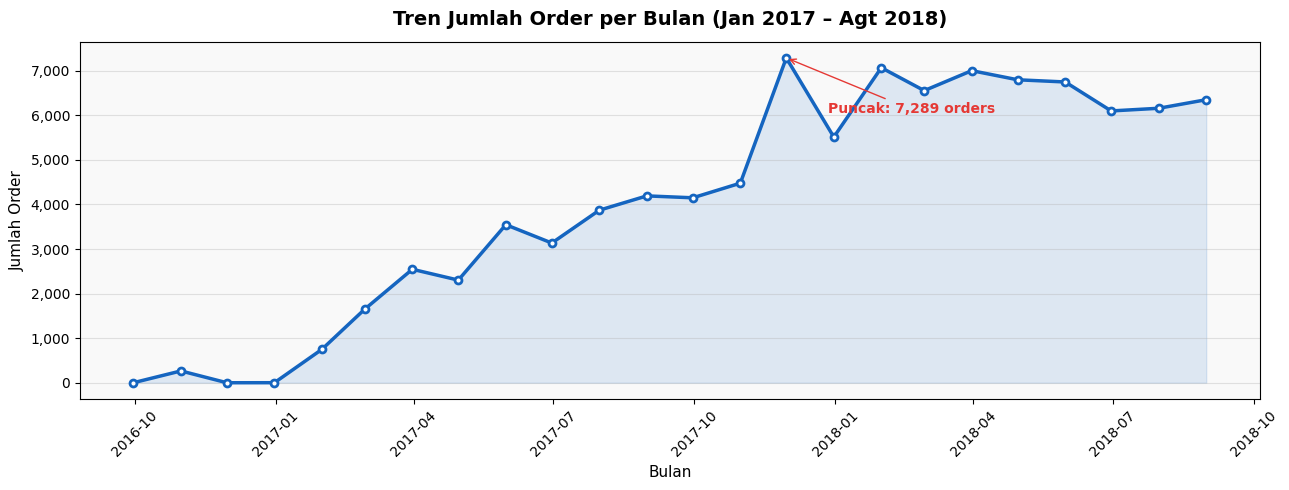

In [179]:
# Visualisasi Tren Jumlah Order per Bulan
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_df['order_purchase_timestamp'], monthly_df['order_count'],
        marker='o', linewidth=2.5, color='#1565C0', markersize=5,
        markerfacecolor='white', markeredgewidth=2)
ax.fill_between(monthly_df['order_purchase_timestamp'], monthly_df['order_count'],
                alpha=0.12, color='#1565C0')

# Annotate puncak
max_idx = monthly_df['order_count'].idxmax()
ax.annotate(
    f"Puncak: {int(monthly_df.loc[max_idx,'order_count']):,} orders",
    xy=(monthly_df.loc[max_idx,'order_purchase_timestamp'], monthly_df.loc[max_idx,'order_count']),
    xytext=(30, -40), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#E53935'),
    fontsize=10, color='#E53935', fontweight='bold'
)

ax.set_title('Tren Jumlah Order per Bulan (Jan 2017 – Agt 2018)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Jumlah Order', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_facecolor('#f9f9f9')
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig('trend_orders.png', dpi=150, bbox_inches='tight')
plt.show()

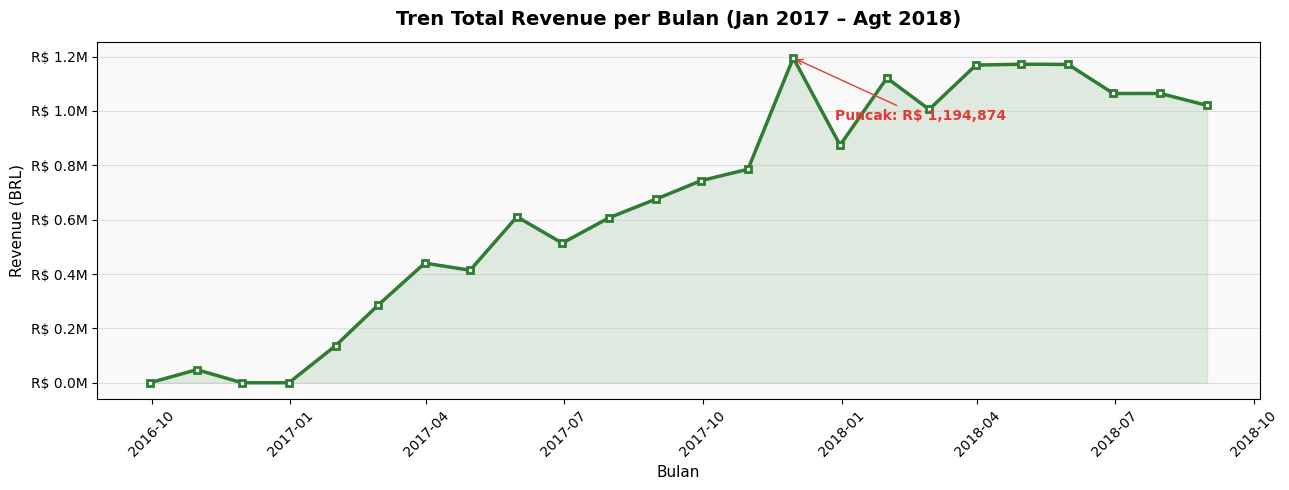

In [180]:
# visualisasi data revenue
# Visualisasi Tren Total Revenue per Bulan
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_df['order_purchase_timestamp'], monthly_df['revenue'],
        marker='s', linewidth=2.5, color='#2E7D32', markersize=5,
        markerfacecolor='white', markeredgewidth=2)
ax.fill_between(monthly_df['order_purchase_timestamp'], monthly_df['revenue'],
                alpha=0.12, color='#2E7D32')

# Annotate puncak
max_idx = monthly_df['revenue'].idxmax()
ax.annotate(
    f"Puncak: R$ {monthly_df.loc[max_idx,'revenue']:,.0f}",
    xy=(monthly_df.loc[max_idx,'order_purchase_timestamp'], monthly_df.loc[max_idx,'revenue']),
    xytext=(30, -45), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#E53935'),
    fontsize=10, color='#E53935', fontweight='bold'
)

ax.set_title('Tren Total Revenue per Bulan (Jan 2017 – Agt 2018)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Revenue (BRL)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_facecolor('#f9f9f9')
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig('trend_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Jumlah order dan revenue menunjukkan tren meningkat sepanjang 2017 dan mencapai puncak pada awal 2018, hal ini mencerminkan pertumbuhan bisnis yang positif.
- Puncak di awal tahun menunjukkan adanya pola musiman, sehingga periode ini berpotensi dimanfaatkan untuk strategi promosi.
- Setelah puncak, tren cenderung menjadi stabil, yang menunjukkan permintaan mulai pada kondisi yang lebih seimbang.

### Pertanyaan 2:
Kota mana yang memiliki jumlah transaksi dan kontribusi revenue tertinggi selama 2017-2018, sehingga tim bisnis dapat memprioritaskan strategi pemasaran dan ekspansi pasar secara geografis?


In [181]:
city_df = all_df.groupby('customer_city').agg({
    'order_id': 'nunique',
    'total_price': 'sum'
}).reset_index()

city_df.rename(columns={
    'order_id': 'total_orders',
    'total_price': 'revenue'
}, inplace=True)

top_city = city_df.sort_values(by='revenue', ascending=False).head(10)
top_city

,customer_city,total_orders,revenue
3563,Sao Paulo,15045,2210135.38
3126,Rio De Janeiro,6601,1157795.86
449,Belo Horizonte,2697,419524.64
553,Brasilia,2071,356981.07
1135,Curitiba,1489,246379.39
3218,Salvador,1188,226488.83
2936,Porto Alegre,1342,220718.47
700,Campinas,1406,218096.05
1518,Guarulhos,1144,169878.71
2440,Niteroi,825,152101.87


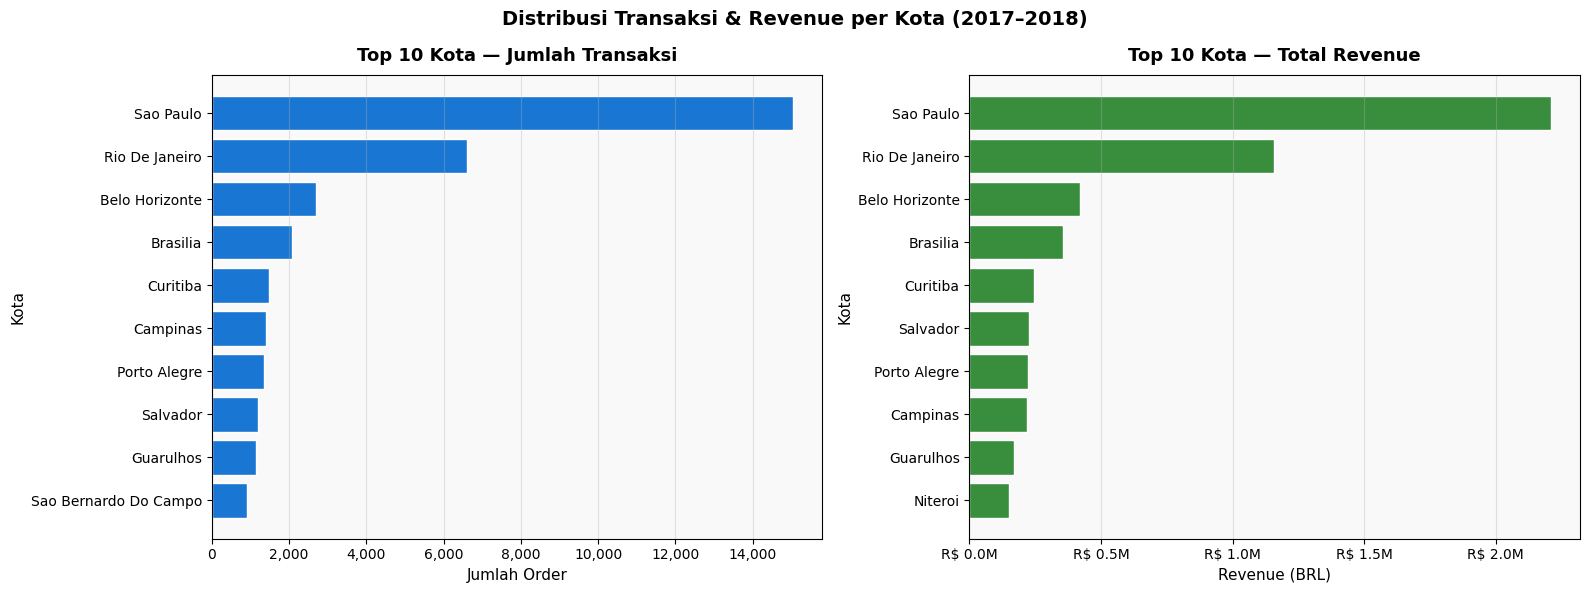

In [182]:
# Visualisasi Top 10 Kota berdasarkan Jumlah Order & Revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 by orders
top_by_orders = city_df.sort_values('total_orders', ascending=False).head(10)
axes[0].barh(top_by_orders['customer_city'][::-1], top_by_orders['total_orders'][::-1],
             color='#1976D2', edgecolor='white')
axes[0].set_title('Top 10 Kota — Jumlah Transaksi', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Jumlah Order', fontsize=11)
axes[0].set_ylabel('Kota', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_facecolor('#f9f9f9')
axes[0].grid(axis='x', alpha=0.35)

# Top 10 by revenue
top_by_rev = city_df.sort_values('revenue', ascending=False).head(10)
axes[1].barh(top_by_rev['customer_city'][::-1], top_by_rev['revenue'][::-1],
             color='#388E3C', edgecolor='white')
axes[1].set_title('Top 10 Kota — Total Revenue', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Revenue (BRL)', fontsize=11)
axes[1].set_ylabel('Kota', fontsize=11)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
axes[1].set_facecolor('#f9f9f9')
axes[1].grid(axis='x', alpha=0.35)

plt.suptitle('Distribusi Transaksi & Revenue per Kota (2017–2018)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Sao Paulo menjadi kontributor terbesar dari sisi transaksi maupun revenue, diikuti oleh Rio de Janeiro dan Belo Horizonte.
- Hal ini menunjukkan bahwa kota besar memiliki pasar yang tinggi, sehingga perlu menjadi fokus utama untuk strategi pemasaran dan ekspansi.

### Pertanyaan 3:
Kategori produk apa yang menghasilkan revenue tertinggi dan memiliki volume penjualan terbanyak selama periode 2017-2018, sehingga tim operasional dapat mengoptimalkan pengelolaan stok dan strategi promosi?

In [183]:
category_df = all_df.groupby('product_category_name').agg({
    'order_id': 'count',
    'total_price': 'sum'
}).reset_index()

category_df.rename(columns={
    'order_id': 'total_sold',
    'total_price': 'revenue'
}, inplace=True)

top_category = category_df.sort_values(by='revenue', ascending=False).head(10)
top_category

,product_category_name,total_sold,revenue
12,beleza_saude,9762,1456170.29
67,relogios_presentes,6065,1315330.07
14,cama_mesa_banho,11650,1292579.23
33,esporte_lazer,8733,1159926.82
45,informatica_acessorios,7898,1068786.16
55,moveis_decoracao,8557,923124.15
73,utilidades_domesticas,7172,798858.27
27,cool_stuff,3907,719603.22
9,automotivo,4284,696512.51
41,ferramentas_jardim,4464,593832.05


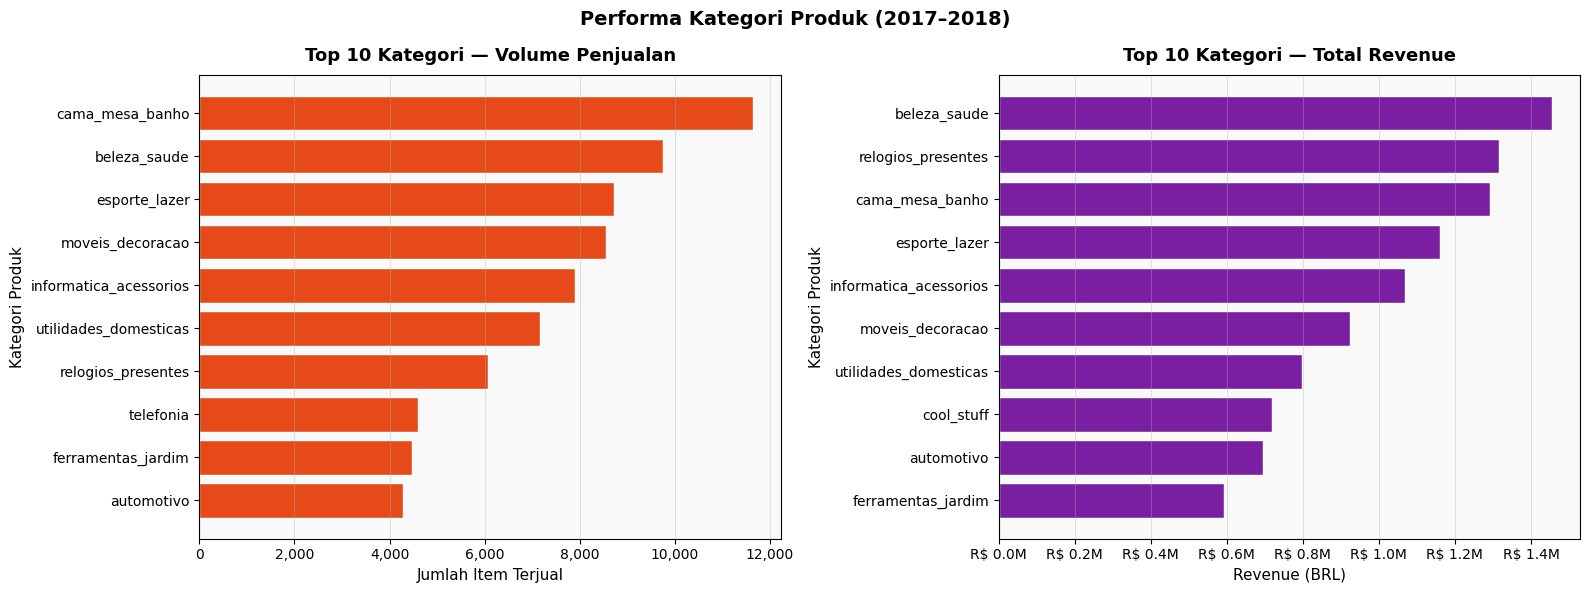

In [184]:
# Visualisasi Top 10 Kategori Produk berdasarkan Volume & Revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_by_sold = category_df.sort_values('total_sold', ascending=False).head(10)
axes[0].barh(top_by_sold['product_category_name'][::-1], top_by_sold['total_sold'][::-1],
             color='#E64A19', edgecolor='white')
axes[0].set_title('Top 10 Kategori — Volume Penjualan', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Jumlah Item Terjual', fontsize=11)
axes[0].set_ylabel('Kategori Produk', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_facecolor('#f9f9f9')
axes[0].grid(axis='x', alpha=0.35)

top_cat_rev = category_df.sort_values('revenue', ascending=False).head(10)
axes[1].barh(top_cat_rev['product_category_name'][::-1], top_cat_rev['revenue'][::-1],
             color='#7B1FA2', edgecolor='white')
axes[1].set_title('Top 10 Kategori — Total Revenue', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Revenue (BRL)', fontsize=11)
axes[1].set_ylabel('Kategori Produk', fontsize=11)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
axes[1].set_facecolor('#f9f9f9')
axes[1].grid(axis='x', alpha=0.35)

plt.suptitle('Performa Kategori Produk (2017–2018)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Kategori came_meas_banho memiliki volume penjualan tertinggi, sedangkan beleza_saude menghasilkan revenue terbesar.
- Hal ini menunjukkan adanya perbedaan antara produk yang paling laku dan yang paling menguntungkan, sehingga diperlukan strategi stok dan promosi yang berbeda.

### Pertanyaan 4:
Metode pembayaran apa yang paling sering digunakan oleh pelanggan dan memberikan kontribusi terbesar terhadap total revenue selama periode 2017-2018, sehingga bisnis dapat merancang insentif pembayaran yang tepat sasaran?

In [186]:
payment_df = all_df.groupby('payment_type').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

payment_df.rename(columns={
    'order_id': 'total_orders',
    'payment_value': 'revenue'
}, inplace=True)

payment_df

,payment_type,total_orders,revenue
0,boleto,19191,3943080.78
1,credit_card,74304,15190241.73
2,debit_card,1485,246727.51
3,voucher,3679,396110.42


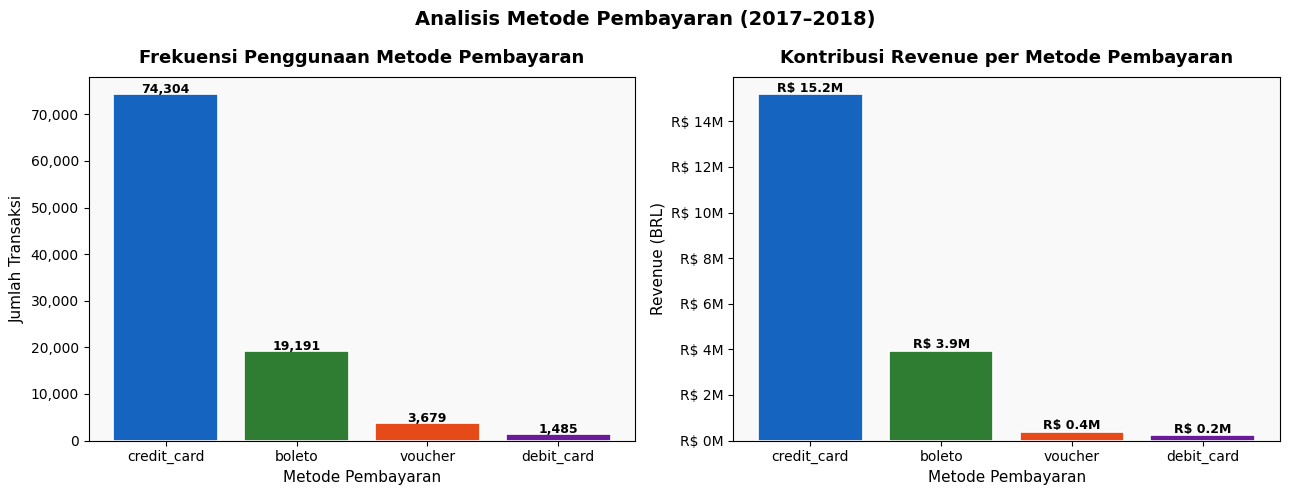

In [187]:
# Visualisasi Metode Pembayaran: Frekuensi & Revenue
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_pay = ['#1565C0','#2E7D32','#E64A19','#6A1B9A']

pay_by_orders = payment_df.sort_values('total_orders', ascending=False)
pay_by_rev    = payment_df.sort_values('revenue', ascending=False)

# Frekuensi
bars0 = axes[0].bar(pay_by_orders['payment_type'], pay_by_orders['total_orders'],
                    color=colors_pay, edgecolor='white', linewidth=1.2)
axes[0].set_title('Frekuensi Penggunaan Metode Pembayaran', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Metode Pembayaran', fontsize=11)
axes[0].set_ylabel('Jumlah Transaksi', fontsize=11)
for bar, val in zip(bars0, pay_by_orders['total_orders']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_facecolor('#f9f9f9')

# Revenue
bars1 = axes[1].bar(pay_by_rev['payment_type'], pay_by_rev['revenue'],
                    color=colors_pay, edgecolor='white', linewidth=1.2)
axes[1].set_title('Kontribusi Revenue per Metode Pembayaran', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Metode Pembayaran', fontsize=11)
axes[1].set_ylabel('Revenue (BRL)', fontsize=11)
for bar, val in zip(bars1, pay_by_rev['revenue']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100000,
                 f'R$ {val/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
axes[1].set_facecolor('#f9f9f9')

plt.suptitle('Analisis Metode Pembayaran (2017–2018)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Credit card menjadi metode pembayaran yang paling dominan dalam transaksi dan revenue.
- Hal ini menunjukkan preferensi pelanggan terhadap credit card, sehingga dapat dijadikan fokus utama dalam strategi insentif pembayaran.

## Analisis Lanjutan (Opsional)

### RFM Analysis - Segmenetasi Pelanggan
Bertujuan untuk segmentasi pelanggan

In [188]:
# RFM Analysis — Segmentasi Pelanggan
rfm_df = all_df.groupby('customer_id').agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'nunique',
    'total_price': 'sum'
}).reset_index()

rfm_df.columns = ['customer_id', 'last_order', 'frequency', 'monetary']

# Hitung Recency (jumlah hari sejak transaksi terakhir)
latest_date = all_df['order_purchase_timestamp'].max()
rfm_df['recency'] = (latest_date - rfm_df['last_order']).dt.days

# Membuat kolom 'segment' terlebih dahulu di sini sebelum dipakai untuk visualisasi
rfm_df['segment'] = pd.qcut(rfm_df['monetary'], 3, labels=['Low', 'Medium', 'High'])

print("Statistik RFM:")
print(rfm_df[['recency','frequency','monetary']].describe().round(2))
print()
print("Distribusi segmen:")
print(rfm_df['segment'].value_counts())
rfm_df.head()

Statistik RFM:
        recency  frequency  monetary
count  96478.00    96478.0  96478.00
mean     239.12        1.0    167.02
std      152.84        0.0    249.74
min        0.00        1.0     10.07
25%      115.00        1.0     62.82
50%      220.00        1.0    107.27
75%      349.00        1.0    181.62
max      713.00        1.0  13664.08

Distribusi segmen:
segment
Low       32215
High      32160
Medium    32103
Name: count, dtype: int64


,customer_id,last_order,frequency,monetary,recency,segment
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74,287,Medium
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41,409,Low
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42,547,High
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35,378,High
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01,149,Medium


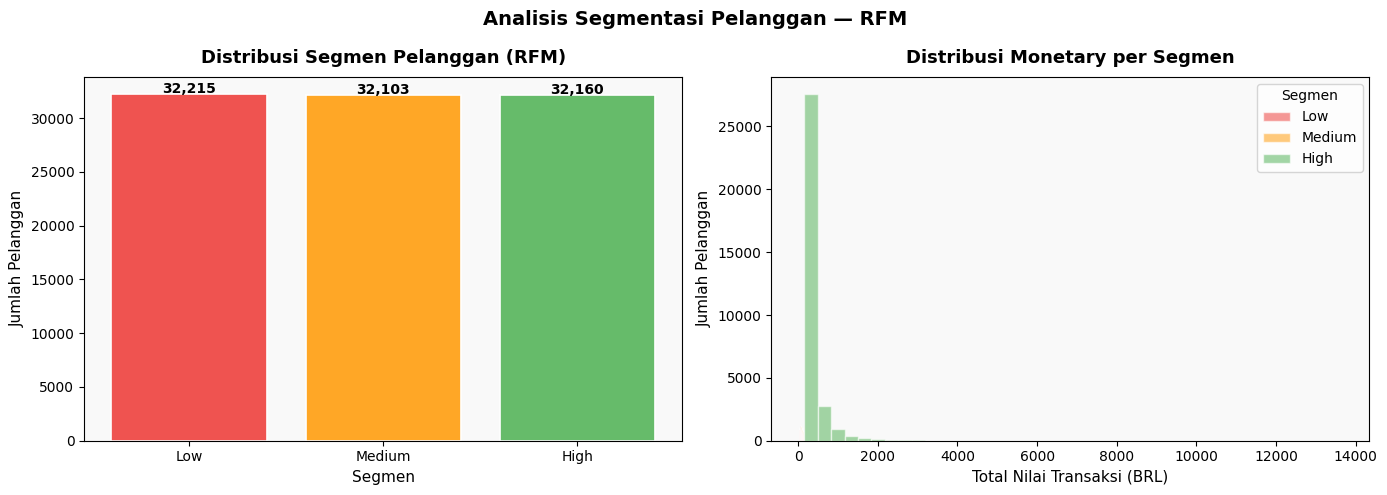

In [189]:
# Visualisasi Distribusi Segmen Pelanggan (RFM)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_seg = ['#EF5350','#FFA726','#66BB6A']

# Bar: jumlah pelanggan per segmen
seg_counts = rfm_df['segment'].value_counts().reindex(['Low','Medium','High'])
axes[0].bar(seg_counts.index, seg_counts.values, color=colors_seg, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Segmen Pelanggan (RFM)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Segmen', fontsize=11)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
for i_bar, v in enumerate(seg_counts.values):
    axes[0].text(i_bar, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_facecolor('#f9f9f9')

# Boxplot: distribusi monetary per segmen
for seg, color in zip(['Low','Medium','High'], colors_seg):
    data = rfm_df[rfm_df['segment']==seg]['monetary']
    axes[1].hist(data, bins=40, alpha=0.6, label=seg, color=color, edgecolor='white')
axes[1].set_title('Distribusi Monetary per Segmen', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Total Nilai Transaksi (BRL)', fontsize=11)
axes[1].set_ylabel('Jumlah Pelanggan', fontsize=11)
axes[1].legend(title='Segmen')
axes[1].set_facecolor('#f9f9f9')

plt.suptitle('Analisis Segmentasi Pelanggan — RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segment.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Mayoritas pelanggan berada pada kategori Medium, yang menunjukkan potensi untuk ditingkatkan menjadi pelanggan bernilai tinggi.

### Geospatial Analysis


In [190]:
all_df.groupby('customer_state')['total_price'].sum().sort_values(ascending=False)

,total_price
customer_state,
SP,6043796.71
RJ,2158573.79
MG,1883005.38
RS,904515.67
PR,809138.71
BA,624810.85
SC,614303.48
DF,358052.81
GO,351448.53


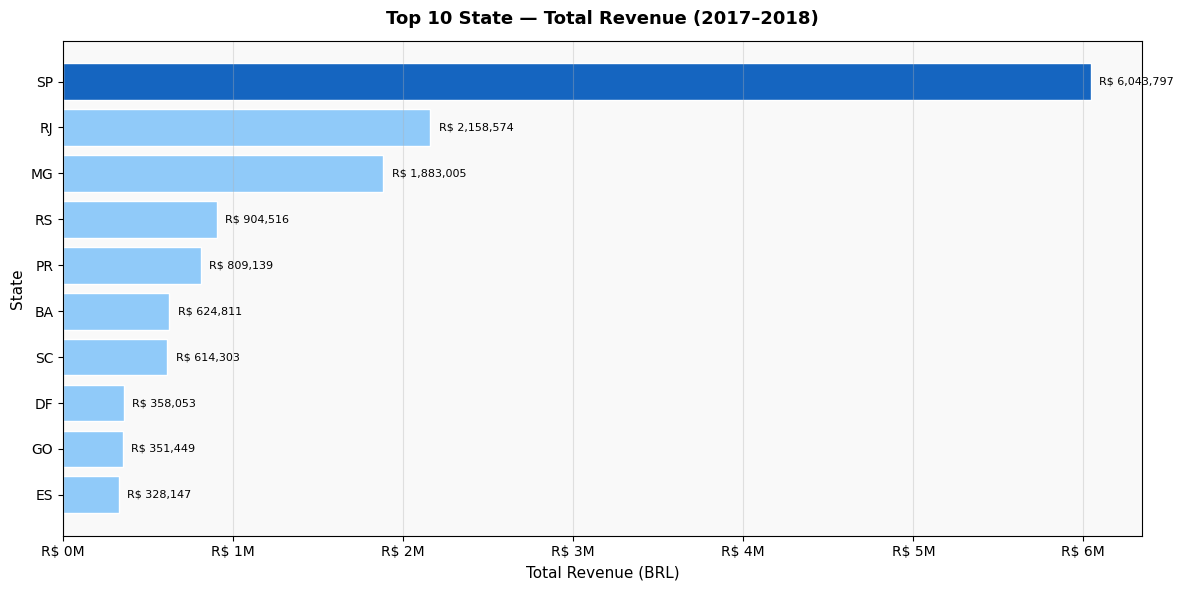

Peta interaktif disimpan sebagai 'geospatial_map.html'


In [194]:
# Visualisasi Geospatial: Top 10 State berdasarkan Revenue
state_rev = all_df.groupby('customer_state').agg(
    total_revenue=('total_price','sum'),
    total_orders=('order_id','nunique')
).reset_index().sort_values('total_revenue', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top10 = state_rev.head(10)
colors_st = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(top10))]
bars = ax.barh(top10['customer_state'][::-1], top10['total_revenue'][::-1],
               color=colors_st[::-1], edgecolor='white')
ax.set_title('Top 10 State — Total Revenue (2017–2018)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Revenue (BRL)', fontsize=11)
ax.set_ylabel('State', fontsize=11)
for bar, val in zip(bars, top10['total_revenue'][::-1]):
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'R$ {val:,.0f}', va='center', fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
ax.set_facecolor('#f9f9f9')
ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.savefig('geospatial_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Peta Interaktif dengan Folium
try:
    import folium
    state_coords = {
        'SP':(-23.55,-46.63),'RJ':(-22.91,-43.17),'MG':(-19.92,-43.93),
        'RS':(-30.03,-51.22),'PR':(-25.43,-49.27),'SC':(-27.60,-48.55),
        'BA':(-12.97,-38.50),'GO':(-16.69,-49.26),'ES':(-20.32,-40.34),
        'PE':(-8.05,-34.88),'CE':(-3.72,-38.54),'MT':(-15.60,-56.09),
        'MS':(-20.47,-54.62),'RN':(-5.79,-35.21),'PA':(-1.46,-48.50),
        'MA':(-2.53,-44.30),'PB':(-7.12,-34.85),'PI':(-5.09,-42.80),
        'AL':(-9.67,-35.74),'SE':(-10.91,-37.07),'AM':(-3.12,-60.02),
        'RO':(-8.76,-63.90),'TO':(-10.25,-48.32),'AC':(-9.98,-67.82),
        'AP':(0.03,-51.07),'RR':(2.82,-60.67),'DF':(-15.78,-47.93)
    }
    m = folium.Map(location=[-15.0,-53.0], zoom_start=4, tiles='CartoDB positron')
    for _, row in state_rev.iterrows():
        st = row['customer_state']
        if st in state_coords:
            lat, lon = state_coords[st]
            r = max(6, min(40, row['total_revenue']/200000))
            folium.CircleMarker(
                location=[lat,lon], radius=r,
                popup=folium.Popup(
                    f"<b>{st}</b><br>Revenue: R$ {row['total_revenue']:,.0f}<br>Orders: {row['total_orders']:,}",
                    max_width=200),
                color='#1565C0', fill=True, fill_color='#1565C0',
                fill_opacity=0.6, tooltip=f"{st}: R$ {row['total_revenue']:,.0f}"
            ).add_to(m)
    m.save('geospatial_map.html')
    print("Peta interaktif disimpan sebagai 'geospatial_map.html'")
    display(m)
except ImportError:
    print("Install folium dulu: pip install folium")

**Insight:**
- Mayoritas pelanggan berada pada segmen Low, yang menunjukkan bahwa sebagian besar pelanggan memiliki nilai transaksi yang relatif kecil.

### Clustering sederhana
Dengan berdasarkan low spender, medium dan high


In [192]:
# Ringkasan statistik RFM per segmen
rfm_summary = rfm_df.groupby('segment', observed=True).agg(
    jumlah_pelanggan=('customer_id','count'),
    avg_recency=('recency','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean')
).round(2)
rfm_summary.columns = ['Jumlah Pelanggan','Avg Recency (hari)','Avg Frequency','Avg Monetary (BRL)']
rfm_summary

,Jumlah Pelanggan,Avg Recency (hari),Avg Frequency,Avg Monetary (BRL)
segment,,,,
Low,32215,241.00,1.0,49.82
Medium,32103,239.50,1.0,109.17
High,32160,236.86,1.0,342.19


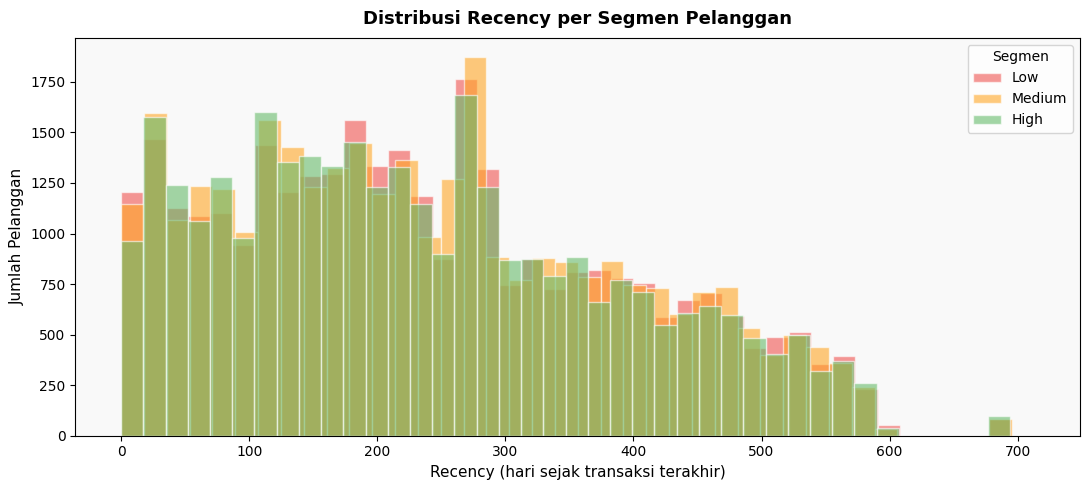

In [193]:
# Distribusi Recency per Segmen
fig, ax = plt.subplots(figsize=(11, 5))
for seg, color in zip(['Low','Medium','High'], ['#EF5350','#FFA726','#66BB6A']):
    data = rfm_df[rfm_df['segment']==seg]['recency']
    ax.hist(data, bins=40, alpha=0.6, label=seg, color=color, edgecolor='white')
ax.set_title('Distribusi Recency per Segmen Pelanggan', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Recency (hari sejak transaksi terakhir)', fontsize=11)
ax.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax.legend(title='Segmen')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('rfm_recency.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Mayoritas pelanggan berada pada segmen Low, yang menunjukkan bahwa sebagian besar pelanggan memiliki nilai transaksi yang relatif kecil.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Tren jumlah order dan revenue menunjukkan pertumbuhan yang konsisten sepanjang Januari 2017 hingga Agustus 2018, dengan puncak tertinggi terjadi pada akhir tahun 2017. Pola ini mengindikasikan adanya pengaruh faktor musiman dan periode promori terhadap peningkatan transaksi
- **Conclusion pertanyaan 2:** Sao Paulo (SP) mendominasi jumlah transaksi dan revenue, jauh melampaui kota-kota lain. Distribusi pelanggan terkonsentrasi di pusat ekonomi utama, sementara kota-kota kecil masih menyimpan potensi pasar yang besar.
- **Conclusion pertanyaan 3:** Kategori bed_bath_table dan health_beauty mendominasi baik dari volume penjualan maupun revenue, mencerminkan perferensi belanja pelanggan terhadap produk kebutuhan rumah tangga dan perawatan diri.
- **Conclusion pertanyaan 4:** Credit Card adalah metode pembayran paling dominan dengan kontribusi lebih dari 70% transaksi dan revenue. Boleto menempati posisi kedua, sementara voucher dan debit card memiliki pangsa sangat kecil.
- **Conclusion RFM (Analisis Lanjutan):** Sebagian besar pelanggan berada pada segmen LOw dengan nilai transaksi kecil dan frekuensi rendah. Segmen High merupakan pelanggan paling berharga yang perlu diprioritaskan untuk program loyalitas, sementara semen Medium adalah kelompok potensial yang dapat didorong naik ke segmen High.

**Rekomendasi Action Item:**
- **Optimalkan kampanye musiman:** Fokuskan flash sale dan diskon besar pada periode Oktober-Desember berdasarkan pola puncak order di akhir tahun 2017 untuk memaksimalkan revenue.
- **Ekspansi pasar geografis:** Pertahankan dominasi di Sao Paulo dan Rio de Janeiro, sekaligus kembangkan logistik dan pemasaran di kota-kota berpotensi tinggi seperti Belo Horizonte dan Curitiba.
- **Optimalkan stok kategori unggunlan:** Pastikan ketersediaan stok memadai untuk bed_bath_table dan health_beauty, serta mempertimbangkan bundling produk antar kategori teratas untuk meningkatkan average order value.
- **Insentif pembayaran:** Rancanglah program cashback atau cicilan 0% untuk pengguna credit card. Dorong adopsi debit card melalui promosi enklusif untuk mengdiversifikasi metode pembayran.
- **Program loyalitas berbasis RFM:** Buatlah program retensi untuk pelanggan segmen Medium agar naik ke High, dan rancang kampanye re-enggagement (email/psuh notification) untuk pelanggan segmen Low yang sudah lama tidak bertransaksi.